Chapter 5 Understand Your Data With Descriptive Statistics

5.1 Peek at Your Data
There is no substitute for looking at the raw data. Looking at the raw data can reveal insights that you cannot get any other way. It can also plant seeds that may later grow into ideas on how to better pre-process and handle the data for machine learning tasks. You can review the first 20 rows of your data using the head() function on the Pandas DataFrame.

In [ ]:
# View first 20 rows
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
peek = data.head(20)
print(peek)

5.2 Dimensions of Your Data
You must have a very good handle on how much data you have, both in terms of rows and columns.
 Too many rows and algorithms may take too long to train. Too few and perhaps you do not have enough data to train the algorithms.
 Too many features and some algorithms can be distracted or suffer poor performance due to the curse of dimensionality.
You can review the shape and size of your dataset by printing the shape property on the Pandas DataFrame.

In [ ]:
# Dimensions of your data
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
shape = data.shape
print(shape)

The results are listed in rows then columns. You can see that the dataset has 768 rows and 9 columns. (768, 9)

5.3 Data Type For Each Attribute
The type of each attribute is important. Strings may need to be converted to floating point values or integers to represent categorical or ordinal values. You can get an idea of the types of attributes by peeking at the raw data, as above. You can also list the data types used by the DataFrame to characterize each attribute using the dtypes property. 

In [ ]:
# Data Types for Each Attribute
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
types = data.dtypes
print(types)

You can see that most of the attributes are integers and that mass and pedi are floating point types.
preg int64
plas int64
pres int64
skin int64
test int64
mass float64
pedi float64
age int64
class int64
dtype: object

5.4 Descriptive Statistics
Descriptive statistics can give you great insight into the shape of each attribute. Often you can create more summaries than you have time to review. The describe() function on the Pandas DataFrame lists 8 statistical properties of each attribute. They are:
 Count.
 Mean.
 Standard Deviation.
 Minimum Value.
 25th Percentile.
 50th Percentile (Median).
 75th Percentile.
 Maximum Value.

In [ ]:
# Statistical Summary
from pandas import read_csv
from pandas import set_option
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
set_option('display.width', 100)
set_option('precision', 3)
description = data.describe()
print(description)

You can see that you do get a lot of data. You will note some calls to pandas.set option() in the recipe to change the precision of the numbers and the preferred width of the output. This is to make it more readable for this example. When describing your data this way, it is worth taking some time and reviewing observations from the results. This might include the presence of NA values for missing data or surprising distributions for attributes.

        preg    plas    pres    skin    test    mass    pedi    age     class
count   768.000 768.000 768.000 768.000 768.000 768.000 768.000 768.000 768.000
mean    3.845   120.895 69.105  20.536  79.799  31.993  0.472   33.241  0.349
std     3.370   31.973  19.356  15.952  115.244 7.884   0.331   11.760  0.477
min     0.000   0.000   0.000   0.000   0.000   0.000   0.078   21.000  0.000
25%     1.000   99.000  62.000  0.000   0.000   27.300  0.244   24.000  0.000
50%     3.000   117.000 72.000  23.000  30.500  32.000  0.372   29.000  0.000
75%     6.000   140.250 80.000  32.000  127.250 36.600  0.626   41.000  1.000
max     17.000  199.000 122.000 99.000  846.000 67.100  2.420   81.000  1.000

5.5 Class Distribution (Classification Only)
On classification problems you need to know how balanced the class values are. Highly imbalanced problems (a lot more observations for one class than another) are common and may need special handling in the data preparation stage of your project. You can quickly get an idea of the distribution of the class attribute in Pandas.

In [ ]:
# Class Distribution
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
class_counts = data.groupby('class').size()
print(class_counts)

You can see that there are nearly double the number of observations with class 0 (no onset of diabetes) than there are with class 1 (onset of diabetes).
class
0       500
1       268

5.6 Correlations Between Attributes
Correlation refers to the relationship between two variables and how they may or may not change together. The most common method for calculating correlation is Pearson’s Correlation Coefficient, that assumes a normal distribution of the attributes involved. A correlation of -1 or 1 shows a full negative or positive correlation respectively. Whereas a value of 0 shows no correlation at all. Some machine learning algorithms like linear and logistic regression can suffer poor performance if there are highly correlated attributes in your dataset. As such, it is a good idea to review all of the pairwise correlations of the attributes in your dataset. You can use the corr() function on the Pandas DataFrame to calculate a correlation matrix.

In [ ]:
# Pairwise Pearson correlations
from pandas import read_csv
from pandas import set_option
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
set_option('display.width', 100)
set_option('precision', 3)
correlations = data.corr(method='pearson')
print(correlations)

The matrix lists all attributes across the top and down the side, to give correlation between all pairs of attributes (twice, because the matrix is symmetrical). You can see the diagonal line through the matrix from the top left to bottom right corners of the matrix shows perfect correlation of each attribute with itself.

        preg    plas    pres    skin    test    mass    pedi    age     class
preg    1.000   0.129   0.141   -0.082  -0.074  0.018   -0.034  0.544   0.222
plas    0.129   1.000   0.153   0.057   0.331   0.221   0.137   0.264   0.467
pres    0.141   0.153   1.000   0.207   0.089   0.282   0.041   0.240   0.065
skin    -0.082  0.057   0.207   1.000   0.437   0.393   0.184   -0.114  0.075
test    -0.074  0.331   0.089   0.437   1.000   0.198   0.185   -0.042  0.131
mass    0.018   0.221   0.282   0.393   0.198   1.000   0.141   0.036   0.293
pedi    -0.034  0.137   0.041   0.184   0.185   0.141   1.000   0.034   0.174
age     0.544   0.264   0.240   -0.114  -0.042  0.036   0.034   1.000   0.238
class   0.222   0.467   0.065   0.075   0.131   0.293   0.174   0.238   1.000

5.7 Skew of Univariate Distributions
Skew refers to a distribution that is assumed Gaussian (normal or bell curve) that is shifted or squashed in one direction or another. Many machine learning algorithms assume a Gaussian distribution. Knowing that an attribute has a skew may allow you to perform data preparation to correct the skew and later improve the accuracy of your models. You can calculate the skew of each attribute using the skew() function on the Pandas DataFrame.

In [ ]:
# Skew for each attribute
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
skew = data.skew()
print(skew)

The skew result show a positive (right) or negative (left) skew. Values closer to zero show less skew.
preg    0.901674
plas    0.173754
pres    -1.843608
skin    0.109372
test    2.272251
mass    -0.428982
pedi    1.919911
age     1.129597
class   0.635017

5.8 Tips To Remember
This section gives you some tips to remember when reviewing your data using summary statistics.
 Review the numbers. Generating the summary statistics is not enough. Take a moment to pause, read and really think about the numbers you are seeing.
 Ask why. Review your numbers and ask a lot of questions. How and why are you seeing specific numbers. Think about how the numbers relate to the problem domain in general and specific entities that observations relate to.
 Write down ideas. Write down your observations and ideas. Keep a small text file or note pad and jot down all of the ideas for how variables may relate, for what numbers mean, and ideas for techniques to try later. The things you write down now while the data is fresh will be very valuable later when you are trying to think up new things to try

5.9 Summary
In this chapter you discovered the importance of describing your dataset before you start work on your machine learning project. You discovered 7 different ways to summarize your dataset using Python and Pandas:
 Peek At Your Data.
 Dimensions of Your Data.
 Data Types.
 Class Distribution.
 Data Summary.
 Correlations.
 Skewness.

5.9.1 Next
Another excellent way that you can use to better understand your data is by generating plots and charts. In the next lesson you will discover how you can visualize your data for machine learning in Python.

Chapter 6
Understand Your Data With Visualization

6.1 Univariate Plots
In this section we will look at three techniques that you can use to understand each attribute of your dataset independently.
 Histograms.
 Density Plots.
 Box and Whisker Plots

6.1.1 Histograms
A fast way to get an idea of the distribution of each attribute is to look at histograms. Histograms group data into bins and provide you a count of the number of observations in each bin. From the shape of the bins you can quickly get a feeling for whether an attribute is Gaussian, skewed or even has an exponential distribution. It can also help you see possible outliers.

In [ ]:
# Univariate Histograms
from matplotlib import pyplot
from pandas import read_csv
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
data.hist()
pyplot.show()

We can see that perhaps the attributes age, pedi and test may have an exponential distribution. We can also see that perhaps the mass and pres and plas attributes may have a Gaussian or nearly Gaussian distribution. This is interesting because many machine learning techniques assume a Gaussian univariate distribution on the input variables.
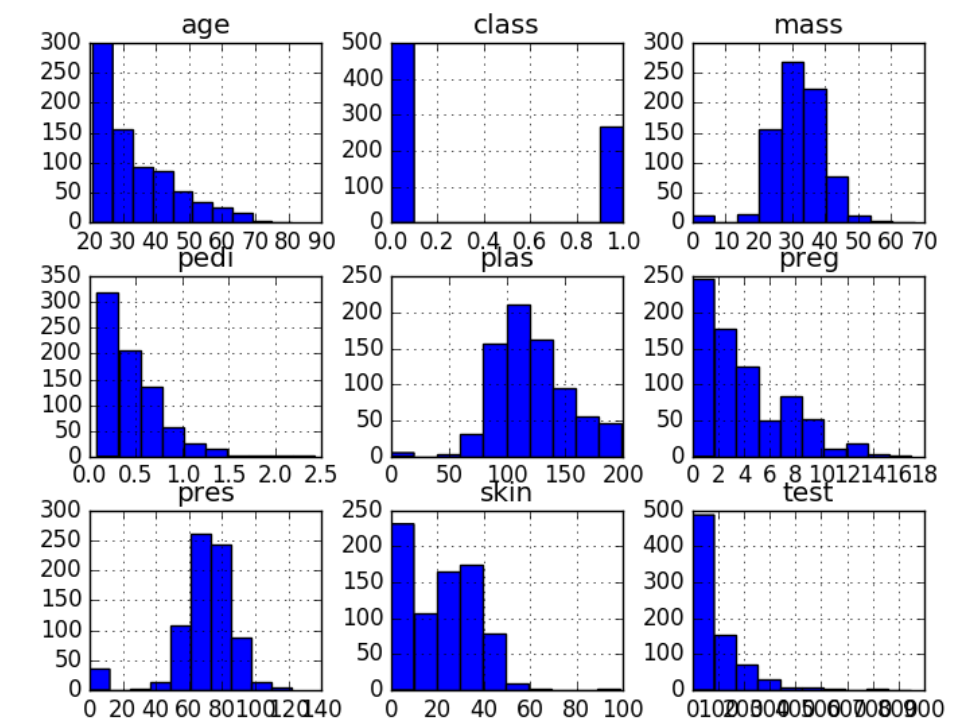

6.1.2 Density Plots
Density plots are another way of getting a quick idea of the distribution of each attribute. The plots look like an abstracted histogram with a smooth curve drawn through the top of each bin, much like your eye tried to do with the histograms.

In [ ]:
# Univariate Density Plots
from matplotlib import pyplot
from pandas import read_csv
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
data.plot(kind='density', subplots=True, layout=(3,3), sharex=False)
pyplot.show()

We can see the distribution for each attribute is clearer than the histograms.
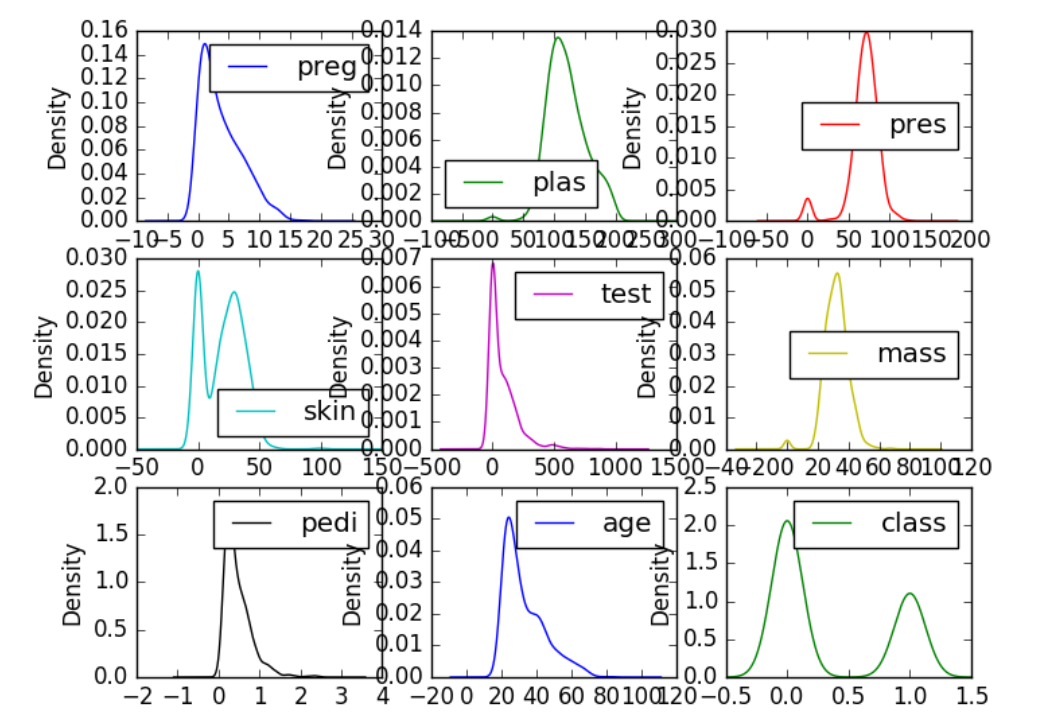

6.1.3 Box and Whisker Plots
Another useful way to review the distribution of each attribute is to use Box and Whisker Plots or boxplots for short. Boxplots summarize the distribution of each attribute, drawing a line for the median (middle value) and a box around the 25th and 75th percentiles (the middle 50% of the data). The whiskers give an idea of the spread of the data and dots outside of the whiskers show candidate outlier values (values that are 1.5 times greater than the size of spread of the middle 50% of the data).

In [ ]:
# Box and Whisker Plots
from matplotlib import pyplot
from pandas import read_csv
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
data.plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False)
pyplot.show()

We can see that the spread of attributes is quite different. Some like age, test and skin appear quite skewed towards smaller values.
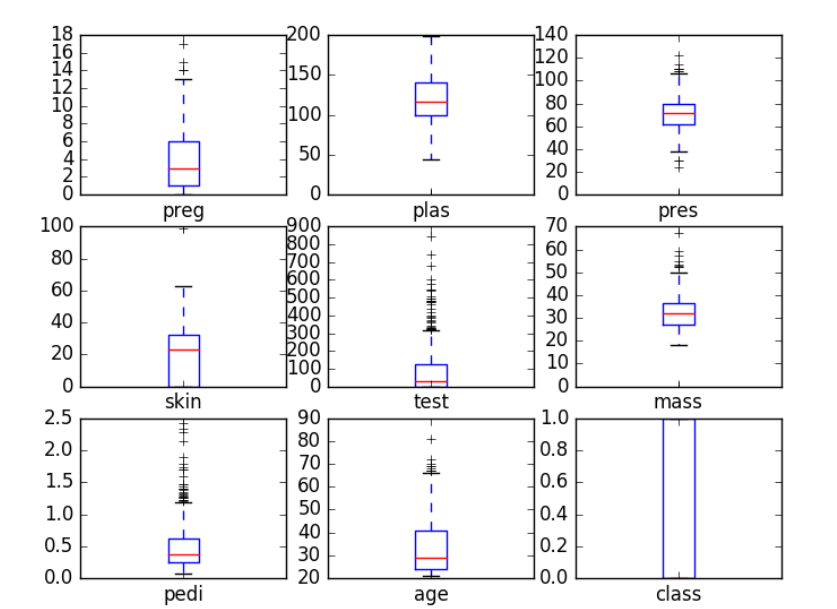

6.2 Multivariate Plots
This section provides examples of two plots that show the interactions between multiple variables in your dataset.
 Correlation Matrix Plot.
 Scatter Plot Matrix.

6.2.1 Correlation Matrix Plot
Correlation gives an indication of how related the changes are between two variables. If two variables change in the same direction they are positively correlated. If they change in opposite directions together (one goes up, one goes down), then they are negatively correlated. You can calculate the correlation between each pair of attributes. This is called a correlation matrix. You can then plot the correlation matrix and get an idea of which variables have a high correlation with each other. This is useful to know, because some machine learning algorithms like linear and logistic regression can have poor performance if there are highly correlated input variables in your data.

In [ ]:
# Correction Matrix Plot
from matplotlib import pyplot
from pandas import read_csv
import numpy
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
correlations = data.corr()
# plot correlation matrix
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = numpy.arange(0,9,1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(names)
ax.set_yticklabels(names)
pyplot.show()

We can see that the matrix is symmetrical, i.e. the bottom left of the matrix is the same as the top right. This is useful as we can see two different views on the same data in one plot. We can also see that each variable is perfectly positively correlated with each other (as you would have expected) in the diagonal line from top left to bottom right.
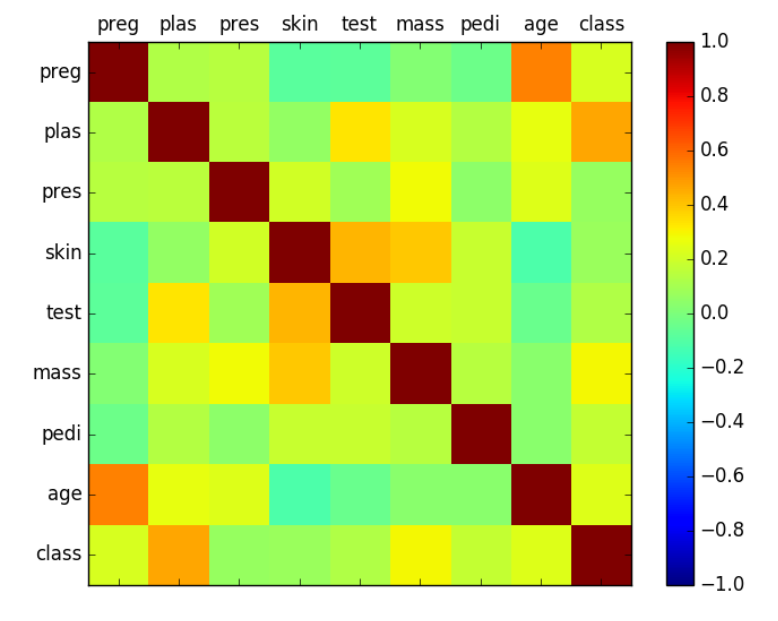
The example is not generic in that it specifies the names for the attributes along the axes as well as the number of ticks. This recipe cam be made more generic by removing these aspects as follows:

In [ ]:
# Correction Matrix Plot (generic)
from matplotlib import pyplot
from pandas import read_csv
import numpy
filename = 'pima-indians-diabetes.data.csv'
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
correlations = data.corr()
# plot correlation matrix
fig = pyplot.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
pyplot.show()

Generating the plot, you can see that it gives the same information although making it a little harder to see what attributes are correlated by name. Use this generic plot as a first cut to understand the correlations in your dataset and customize it like the first example in order to read off more specific data if needed.
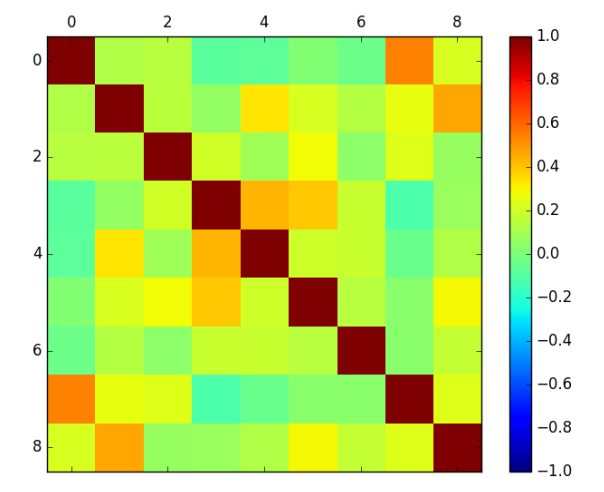

6.2.2 Scatter Plot Matrix
A scatter plot shows the relationship between two variables as dots in two dimensions, one axis for each attribute. You can create a scatter plot for each pair of attributes in your data.
Drawing all these scatter plots together is called a scatter plot matrix. Scatter plots are useful for spotting structured relationships between variables, like whether you could summarize the relationship between two variables with a line. Attributes with structured relationships may also be correlated and good candidates for removal from your dataset.

In [ ]:
# Scatterplot Matrix
from matplotlib import pyplot
from pandas import read_csv
from pandas.tools.plotting import scatter_matrix
filename = "pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = read_csv(filename, names=names)
scatter_matrix(data)
pyplot.show()

Like the Correlation Matrix Plot above, the scatter plot matrix is symmetrical. This is useful to look at the pairwise relationships from different perspectives. Because there is little point of drawing a scatter plot of each variable with itself, the diagonal shows histograms of each attribute.
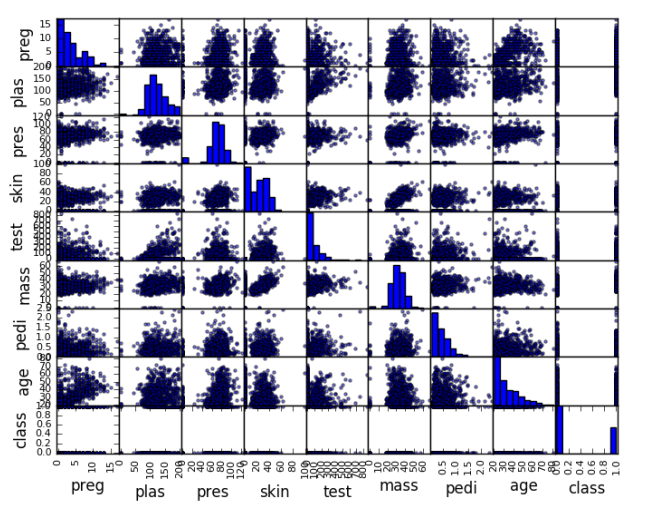

6.3 Summary
In this chapter you discovered a number of ways that you can better understand your machine learning data in Python using Pandas. Specifically, you learned how to plot your data using:
 Histograms.
 Density Plots.
 Box and Whisker Plots.
 Correlation Matrix Plot.
 Scatter Plot Matrix.

6.3.1 Next
Now that you know two ways to learn more about your data, you are ready to start manipulating it. In the next lesson you will discover how you can prepare your data to best expose the structure of your problem to modeling algorithms.